# Tip Data

## Description

A waiter recorded information about every tip he received over the course of several months working at a single restaurant.

## Format

A data table with 244 rows and 7 variables

## Details

- tip in dollars,
- bill in dollars,
- gender of the person paying the bill,
- whether there were smokers in the group,
- day of the week,
- time of day,
- group size.

In total, he recorded 244 tips. The data were published in a collection of case studies for business statistics (Bryant & Smith 1995).

### References

Bryant, P. G. and Smith, M (1995) Practical Data Analysis: Case Studies in Business Statistics. Homewood, IL: Richard D. Irwin Publishing:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("tips")

In [3]:
df['sex']=df['sex'].astype('category')
df['smoker']=df['smoker'].astype('category')
df['day']=df['day'].astype('category')
df['time']=df['time'].astype('category')
print(*df.dtypes)

float64 float64 category category category category int64


In [4]:
print(*df.isna().any())

False False False False False False False


In [5]:
df.sort_values(by='tip').head()

,total_bill,tip,sex,smoker,day,time,size
67,3.07,1.00,Female,Yes,Sat,Dinner,1
236,12.60,1.00,Male,Yes,Sat,Dinner,2
92,5.75,1.00,Female,Yes,Fri,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
0,16.99,1.01,Female,No,Sun,Dinner,2


In [6]:
df.sort_values(by='total_bill', ascending = False).head(3)

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4


## Univariate non-graphical exploratory data analysis

In [7]:
df.describe(include=['category'])

,sex,smoker,day,time
count,244,244,244,244
unique,2,2,4,2
top,Male,No,Sat,Dinner
freq,157,151,87,176


In [8]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


# Correlations

# 1. Total bill [USD] vs. Tips [USD]

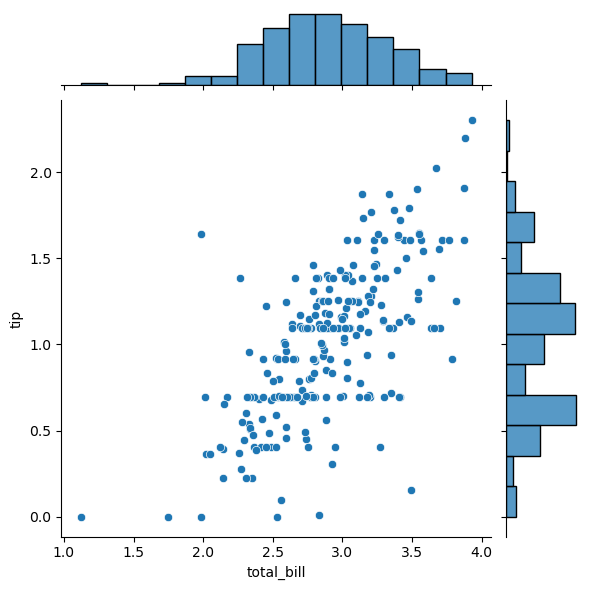

In [ ]:
log_bill = np.log(df['total_bill'])
log_tip = np.log(df['tip'])
sns.jointplot(data=df, x=log_bill, y=log_tip)

In [ ]:
from scipy.stats import pearsonr
pearsonr(log_bill, log_tip)

PearsonRResult(statistic=0.6795702560274505, pvalue=2.0794565165370727e-34)

# 2. Tips [USD] vs. Group size

<AxesSubplot:xlabel='size', ylabel='tip'>

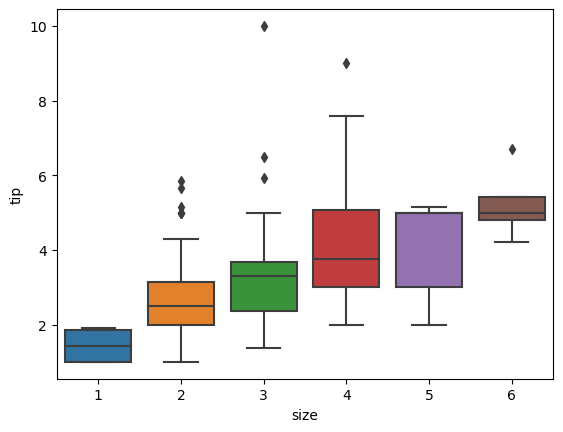

In [25]:
sns.boxplot(data=df, x=df['size'], y=df['tip'])

In [ ]:
from scipy.stats import kendalltau # zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxcccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc
kendalltau(df['size'], df['tip'])

KendalltauResult(correlation=0.3781847296598378, pvalue=7.302407699520677e-14)

# 3. Using the tips dataset, investigate the association between pairs of categorical variables.

Select suitable pairs of qualitative variables (e.g., sex, smoker, day, time) and:

- Create contingency tables.
- Visualize the relationships using count plots or stacked bar charts.
- Perform a Chi-square test of independence.
- Calculate an appropriate measure of association for categorical variables:
  - Phi coefficient (for 2×2 tables)
  - Cramér’s V (for larger contingency tables)
- Interpret the strength and practical meaning of the relationships.

<AxesSubplot:xlabel='time', ylabel='count'>

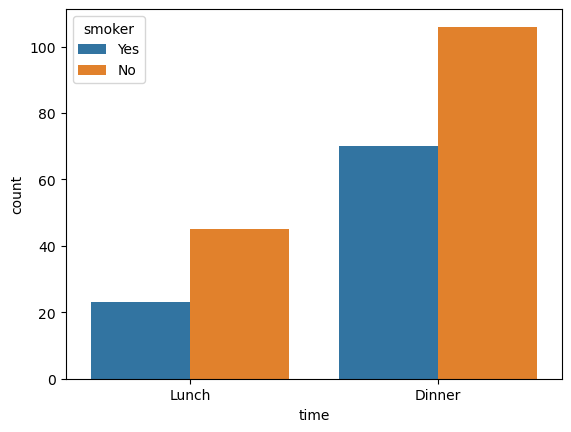

In [30]:
sns.countplot(data=df, x='time', hue='smoker')

In [34]:
ct1 = pd.crosstab(df['smoker'], df['time']) #contingency table


In [35]:
from scipy.stats import chi2_contingency
chi2_contingency(ct1)

(0.5053733928754355,
 0.4771485672079724,
 1,
 array([[ 25.91803279,  67.08196721],
        [ 42.08196721, 108.91803279]]))

In [37]:
from scipy.stats.contingency import association
association(ct1)

#V = association(ct, method="cramer") for larger contingency tables


0.054921103595707566

homework: TOTAL BILLS vs TIME relationship how to find / plot / measure
answer: binning to change the scale, lose the information - to have two nominal scales and do it same way as otherwise